In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import SimpleITK as sitk
import os
import pytomography
from pytomography.io.SPECT import dicom
from pytomography.projectors.SPECT import SPECTSystemMatrix
from pytomography.algorithms import OSEM
from pytomography.likelihoods import PoissonLogLikelihood
from pytomography.transforms.SPECT import SPECTAttenuationTransform, SPECTPSFTransform
from pytomography.utils import plot_utils, ESSEScatterModel
from pytomography.metadata.SPECT import SPECTObjectMeta, SPECTProjMeta
import json

In [2]:
config = {
    "num_projections": 5,
    "pixel_size_cm": 0.44,
    "matrix_size": 128,
    "filenames": {
        "primary": "projections_primary.mhd",
        "scatter": "projections_scatter.mhd",
        "total": "projections_total.mhd"
    },
    "raws": {
        "primary": "projections_primary.raw",
        "scatter": "projections_scatter.raw",
        "total": "projections_total.raw"
    }
}

# path = '../../../../simulations-kernel-esse/validation_tests/output_spect_res_simu_we/'
path = '../../../../simulations-kernel-esse/validation_tests/output_spect/'

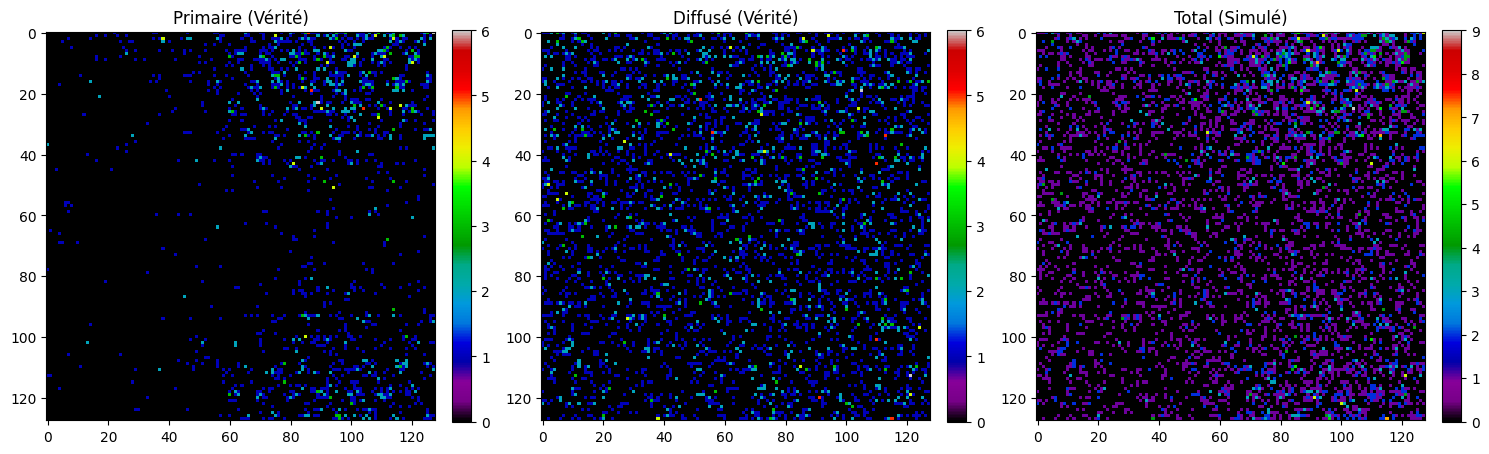

In [3]:
def load_gate_projection(filename):
    img = sitk.ReadImage(filename)
    data = sitk.GetArrayFromImage(img)
    return torch.tensor(data.astype(np.float32))

# Chargement des données
proj_primary = load_gate_projection(path + config["filenames"]["primary"])
proj_scatter = load_gate_projection(path + config["filenames"]["scatter"])
proj_total = load_gate_projection(path + config["filenames"]["total"])

# Affichage d'une projection (ex: angle 0)
angle_idx = 0
plt.figure(figsize=(15, 5))
titles = ['Primaire (Vérité)', 'Diffusé (Vérité)', 'Total (Simulé)']
projs = [proj_primary[angle_idx], proj_scatter[angle_idx], proj_total[angle_idx]]

for i, (p, t) in enumerate(zip(projs, titles)):
    plt.subplot(1, 3, i+1)
    plt.title(t)
    plt.imshow(p.cpu(), cmap='nipy_spectral')
    plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [4]:
def check_raw_integrity(filepath, shape=(20, 128, 128)):
    if not os.path.exists(filepath):
        print(f"Fichier introuvable : {filepath}")
        return

    # Lecture du binaire brut (float32 car MET_FLOAT dans votre mhd)
    data = np.fromfile(filepath, dtype=np.float32)
    
    print(f"--- Analyse de {os.path.basename(filepath)} ---")
    print(f"Nombre total d'éléments : {data.size}")
    print(f"Somme totale des comptes : {data.sum()}")
    print(f"Valeur Max : {data.max()}")
    print(f"Valeur Min : {data.min()}")
    print(f"Nombre de pixels non nuls : {np.count_nonzero(data)}")
    
    if data.size == np.prod(shape):
        data = data.reshape(shape)
        print("Formatage réussi.")
    else:
        print(f"Attention : Taille attendue {np.prod(shape)} mais trouvé {data.size}")
    print("-" * 30)

check_raw_integrity(os.path.join(path, config["raws"]["primary"]))
check_raw_integrity(os.path.join(path, config["raws"]["scatter"]))
check_raw_integrity(os.path.join(path, config["raws"]["total"]))

--- Analyse de projections_primary.raw ---
Nombre total d'éléments : 81920
Somme totale des comptes : 1972.0
Valeur Max : 6.0
Valeur Min : 0.0
Nombre de pixels non nuls : 1516
Attention : Taille attendue 327680 mais trouvé 81920
------------------------------
--- Analyse de projections_scatter.raw ---
Nombre total d'éléments : 81920
Somme totale des comptes : 5016.0
Valeur Max : 6.0
Valeur Min : 0.0
Nombre de pixels non nuls : 3952
Attention : Taille attendue 327680 mais trouvé 81920
------------------------------
--- Analyse de projections_total.raw ---
Nombre total d'éléments : 81920
Somme totale des comptes : 6988.0
Valeur Max : 9.0
Valeur Min : 0.0
Nombre de pixels non nuls : 4988
Attention : Taille attendue 327680 mais trouvé 81920
------------------------------


In [5]:


path = '../../../../simulations-kernel-esse/validation_tests/nema_final_sim/projections_nema_counts.raw'

check_raw_integrity(path)

--- Analyse de projections_nema_counts.raw ---
Nombre total d'éléments : 49152
Somme totale des comptes : 2463.0
Valeur Max : 30.0
Valeur Min : 0.0
Nombre de pixels non nuls : 900
Attention : Taille attendue 327680 mais trouvé 49152
------------------------------


In [6]:
path = '/home/chloe/SPECT'  # Personal computer

pathCT = os.path.join(path, 'Lu177-NEMA-SymT2', 'CT')
files_CT = [os.path.join(pathCT, file) for file in os.listdir(pathCT)]



current_dir = os.getcwd()
DATADIR = os.path.join(current_dir, '../../../src/pytomography/data/NIST_attenuation_data')
FILE_WATER = os.path.join(DATADIR, 'water.csv')

In [7]:
pytomography.device = 'cpu'
pytomography.dtype = torch.float32

energy = 208.0
nb_iter=20
nb_subset=8
index_peak = 0
photopeak_total = proj_total.to(pytomography.device)
photopeak_primary = proj_primary.to(pytomography.device)

In [8]:
# object_meta, proj_meta = dicom.get_metadata(file_NM)
projections = photopeak_total
projections_primary = photopeak_primary
attenuation_map_total = dicom.get_attenuation_map_from_CT_slices(files_CT, photopeak_total)
attenuation_map_primary = dicom.get_attenuation_map_from_CT_slices(files_CT, photopeak_primary)
mu_water = pytomography.utils.get_mu_from_spectrum_interp(FILE_WATER, energy)

TypeError: dcmread: Expected a file path, file-like or readable buffer, but got Tensor

In [9]:
att_transform_total = SPECTAttenuationTransform(attenuation_map=attenuation_map_total)
att_transform_primary = SPECTAttenuationTransform(attenuation_map=attenuation_map_primary)
collimator_name = 'SY-ME'               #todo: automatiser la récupération du collimateur à partir des métadonnées 
energy_kev = energy
intrinsic_resolution=0.35 # todo : à vérifier ??
psf_meta = dicom.get_psfmeta_from_scanner_params(
        collimator_name,
        energy_kev,
        intrinsic_resolution=intrinsic_resolution
)
psf_transform = SPECTPSFTransform(psf_meta)

with open("metadata_pytomography.json", "r") as f:
    meta_json = json.load(f)

# Instanciation automatique
proj_meta = SPECTProjMeta(
    projection_shape=(meta_json['simulation_params']['matrix_size'], 
                      meta_json['simulation_params']['matrix_size']),
    angles=np.array(meta_json['geometry']['angles']),
    radii=np.array(meta_json['geometry']['radii_cm']),
    dr=(meta_json['simulation_params']['pixel_size_cm'], 
        meta_json['simulation_params']['pixel_size_cm'])
)

NameError: name 'attenuation_map_total' is not defined

In [ ]:
system_matrix_no_correction = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_total, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_no_correction = PoissonLogLikelihood(system_matrix_no_correction, photopeak_total)
algorithm_no_correction = OSEM(likelihood_no_correction)

In [ ]:
recon_no_correction = algorithm_no_correction(n_iters=nb_iter, n_subsets=nb_subset)

In [ ]:
system_matrix_no_scatter = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_primary, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_no_scatter = PoissonLogLikelihood(system_matrix_no_scatter, photopeak_primary)
algorithm_no_scatter = OSEM(likelihood_no_scatter)

In [ ]:
recon_no_scatter = algorithm_no_scatter(n_iters=nb_iter, n_subsets=nb_subset)

In [ ]:
# index_peak, index_lower, index_upper = 1, 0, 2
# scatter_TEW = dicom.get_energy_window_scatter_estimate_projections(file_NM, projections, index_peak=index_peak, index_lower=index_lower, index_upper=index_upper, sigma_theta=2, sigma_r=0.48, sigma_z=0.48, proj_meta=proj_meta)

# system_matrix_TEW = SPECTSystemMatrix(
#         obj2obj_transforms = [att_transform_total, psf_transform],
#         proj2proj_transforms = [],
#         object_meta = object_meta,
#         proj_meta = proj_meta)

# likelihood_TEW = PoissonLogLikelihood(system_matrix_TEW, photopeak_total, scatter_TEW)
# algorithm_TEW = OSEM(likelihood_TEW)

In [ ]:
npy_file = '../../../../simulations-kernel-esse/output/esse_kernels_3d.npy'
npy_file_amu = '../../../../simulations-kernel-esse/output/esse_amu_kernels_3d.npy'

from scipy.ndimage import gaussian_filter
def get_real_esse_kernels(npy_path, npy_path_amu, grid_size):

    Z_t, Y_t, X_t = grid_size

    # --- LOAD ---
    raw_k0 = np.load(npy_path)
    raw_amu = np.load(npy_path_amu)

    # raw_k0 = gaussian_filter(raw_k0, sigma=(1.5, 0, 1.5))
    # raw_amu = gaussian_filter(raw_amu, sigma=(1.5, 0, 1.5))

    # --- FORMAT ---
    if raw_k0.ndim == 3:
        k0 = np.transpose(raw_k0, (1, 2, 0))
        amu = np.transpose(raw_amu, (1, 2, 0))
    else:
        k0 = raw_k0
        amu = raw_amu

    # --- TAYLOR TERMS ---
    K0 = k0
    K1 = k0 * amu
    K2 = 0.5 * k0 * (amu ** 2)

    def pad_kernel(data):
        Z_s, Y_s, X_s = data.shape 

        pad_z = Z_t - Z_s
        pad_y = Y_t - Y_s
        pad_x = X_t - X_s

        paddings = (
            pad_x // 2, pad_x - (pad_x // 2), # Dim X
            pad_y // 2, pad_y - (pad_y // 2), # Dim Y
            pad_z // 2, pad_z - (pad_z // 2)  # Dim Z
        )

        tensor = torch.from_numpy(data).float()
        return torch.nn.functional.pad(tensor, paddings)

    # --- APPLY PADDING ---
    k0_t = pad_kernel(K0)
    k1_t = pad_kernel(K1)
    k2_t = pad_kernel(K2)

    # --- STACK FINAL ---
    final_kernels = torch.stack([
        k0_t,
        k1_t,
        k2_t
    ])

    return final_kernels

In [ ]:
# Initilization

esse = ESSEScatterModel(
    object_meta=object_meta,
    attenuation_map=attenuation_map_total,
    energy=208.4,
    mu_water=mu_water,
    kernels=get_real_esse_kernels(
        npy_path=npy_file,
        npy_path_amu=npy_file_amu,
        grid_size=object_meta.padded_shape
    )
)

system_matrix_ESSE = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_total, psf_transform],
    proj2proj_transforms = [],
    object_meta = object_meta,
    proj_meta = proj_meta,
    scatter_model=esse
)

likelihood_ESSE = PoissonLogLikelihood(system_matrix_ESSE, photopeak_total)
algorithm_ESSE = OSEM(likelihood_ESSE)

In [ ]:
recon_ESSE = algorithm_ESSE(n_iters=nb_iter, n_subsets=nb_subset)

In [ ]:
def plot_comparative_spect(recon1, recon2, vmax, label1, label2, slice_idx=None):
    if slice_idx is None:
        slice_idx = recon1.shape[-1] // 2
    # vmax_comum = max(recon.max().item(), reconCGSM.max().item())

    recon1_CPU = recon1.cpu().numpy() if hasattr(recon1, 'is_cuda') and recon1.is_cuda else (recon1.numpy() if hasattr(recon1, 'numpy') else recon1)
    recon2_CPU = recon2.cpu().numpy() if hasattr(recon2, 'is_cuda') and recon2.is_cuda else (recon2.numpy() if hasattr(recon2, 'numpy') else recon2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # RECONSTRUCTION 1
    im1 = axes[0].imshow(recon1_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    axes[0].set_title(f'{label1} ({nb_iter} iter, {nb_subset} subsets)')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], label='Intensity')

    # RECONSTRUCTION 2
    im2 = axes[1].imshow(recon2_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    axes[1].set_title(f'{label2} ({nb_iter} iter, {nb_subset} subsets)')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], label='Intensity')

    # DIFFÉRENCE
    diff = recon1_CPU - recon2_CPU
    im3 = axes[2].imshow(diff[:, :, slice_idx], cmap='RdBu_r', origin='lower')
    axes[2].set_title(f'Différence ({label1} - {label2})')
    axes[2].axis('off')
    plt.colorbar(im3, ax=axes[2], label='Δ Intensity')

In [ ]:
recon_max = recon_no_correction.max().item()
recon_min = recon_no_correction.min().item()
print(f"No correction reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}

slice_idx = 62

plt.figure(figsize=(6, 4))
plt.title(f'No correction Reconstruction (z={slice_idx})')
plt.imshow(recon_no_correction.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
recon_max = recon_no_scatter.max().item()
recon_min = recon_no_scatter.min().item()
print(f"No scatter reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}

slice_idx = 62

plt.figure(figsize=(6, 4))
plt.title(f'No scatter Reconstruction (z={slice_idx})')
plt.imshow(recon_no_scatter.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
recon_max = recon_ESSE.max().item()
recon_min = recon_ESSE.min().item()
print(f"ESSE reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}

slice_idx = 62

plt.figure(figsize=(6, 4))
plt.title(f'ESSE Reconstruction (z={slice_idx})')
plt.imshow(recon_ESSE.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

#print the sum of all voxels in the reconstructions
print(f"Sum of voxels in recon_no_correction: {recon_no_correction.sum().item():.2e}")
print(f"Sum of voxels in recon_TEW: {recon_no_scatter.sum().item():.2e}")
print(f"Sum of voxels in recon_ESSE: {recon_ESSE.sum().item():.2e}")